# Solar AI Diagnostic — Analyse complète du modèle

**Objectif :** Valider scientifiquement le pipeline de classification de défauts photovoltaïques  
**Dataset :** 6 000 mesures réelles simulées · 8 classes · 16 features physiques  
**Modèle :** Random Forest (300 arbres) + Isolation Forest (détection d'anomalies)

---
| Étape | Contenu |
|---|---|
| 1 | Import & configuration |
| 2 | Exploration des données (EDA) |
| 3 | Analyse physique par classe |
| 4 | Entraînement et métriques |
| 5 | Matrice de confusion |
| 6 | Courbes ROC (one-vs-rest) |
| 7 | Importance des features |
| 8 | Séparabilité PCA 2D |
| 9 | Analyse des erreurs |
| 10 | Conclusion |


In [1]:
# ── 1. Import & configuration ────────────────────────────────────────
import sys, warnings
sys.path.insert(0, '../backend')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

from utils.feature_engineering import engineer_features

# ── Palette couleurs par classe ──
PALETTE = {
    0: '#3ecf8e',  # Normal — vert
    1: '#f5a623',  # Ombrage — ambre
    2: '#e05252',  # Court-circuit — rouge
    3: '#c43e3e',  # Circuit ouvert — rouge foncé
    4: '#a259e6',  # PID — violet
    5: '#4cb8f5',  # Encrassement — bleu ciel
    6: '#f57c23',  # Défaut connexion — orange
    7: '#8899aa',  # Vieillissement — gris bleu
}
NOMS = [
    'Normal', 'Ombrage partiel', 'Court-circuit', 'Circuit ouvert',
    'Dégradation PID', 'Encrassement', 'Défaut connexion', 'Vieillissement'
]
COLORS = [PALETTE[i] for i in range(8)]

# ── Style global ──
plt.rcParams.update({
    'figure.facecolor': '#0d0f14',
    'axes.facecolor':   '#161b27',
    'axes.edgecolor':   '#252d3f',
    'axes.labelcolor':  '#e8eaf0',
    'axes.titlecolor':  '#e8eaf0',
    'xtick.color':      '#7a8299',
    'ytick.color':      '#7a8299',
    'text.color':       '#e8eaf0',
    'grid.color':       '#252d3f',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

print('✓ Imports OK')

✓ Imports OK


In [2]:
# ── 2. Chargement et aperçu du dataset ──────────────────────────────
df_raw = pd.read_csv('../backend/data/solar_faults.csv')
df     = engineer_features(df_raw)

FEATURES_BRUTES = [
    'irradiance', 'temperature_panneau', 'temperature_ambiante',
    'tension_voc', 'courant_isc', 'puissance_mpp', 'tension_mpp',
    'courant_mpp', 'resistance_serie', 'resistance_shunt', 'fill_factor',
    'efficacite', 'temps_fonctionnement', 'humidite', 'vitesse_vent',
    'facteur_idealite',
]
FEATURES_DERIVEES = [
    'performance_ratio', 'delta_temperature', 'ratio_impp_isc',
    'ratio_vmpp_voc', 'rs_normalise', 'score_vieillissement',
]
ALL_FEATURES = FEATURES_BRUTES + FEATURES_DERIVEES

print(f'Shape         : {df.shape}')
print(f'Features      : {len(ALL_FEATURES)} ({len(FEATURES_BRUTES)} brutes + {len(FEATURES_DERIVEES)} dérivées)')
print(f'Classes       : {df["classe"].nunique()}')
print(f'Valeurs nulles: {df.isnull().sum().sum()}')
print()
df[ALL_FEATURES + ['classe']].describe().round(2)

Shape         : (6000, 23)
Features      : 22 (16 brutes + 6 dérivées)
Classes       : 8
Valeurs nulles: 0



,irradiance,temperature_panneau,temperature_ambiante,tension_voc,courant_isc,puissance_mpp,tension_mpp,courant_mpp,resistance_serie,resistance_shunt,...,humidite,vitesse_vent,facteur_idealite,performance_ratio,delta_temperature,ratio_impp_isc,ratio_vmpp_voc,rs_normalise,score_vieillissement,classe
count,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,...,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00,6000.00
mean,691.00,45.91,22.86,33.47,5.55,162.44,24.50,5.51,1.76,2747.34,...,54.19,8.60,1.49,0.42,23.06,0.77,0.72,0.35,0.24,3.50
std,234.86,15.18,10.45,9.36,3.37,118.59,12.59,3.47,1.62,2541.90,...,20.51,5.23,0.25,0.30,17.73,0.31,0.31,0.32,0.19,2.29
min,54.88,15.00,-5.00,1.90,0.00,0.00,0.00,0.00,0.10,100.00,...,10.00,0.00,1.00,0.00,-24.82,0.00,0.00,0.02,0.00,0.00
25%,504.72,33.70,14.87,30.47,2.41,40.89,16.15,2.77,0.55,491.64,...,37.80,4.26,1.30,0.18,10.17,0.68,0.69,0.11,0.09,1.75
50%,695.13,45.35,23.18,35.87,6.34,163.78,29.41,5.70,0.96,1985.84,...,54.42,8.47,1.47,0.41,22.52,0.89,0.82,0.19,0.21,3.50
75%,882.01,57.23,31.13,40.07,8.25,248.53,33.95,8.12,2.85,4506.44,...,70.44,12.60,1.69,0.64,35.45,1.00,0.94,0.57,0.35,5.25
max,1179.57,85.00,45.00,47.95,11.86,438.92,41.31,13.00,5.00,9209.85,...,95.00,20.00,2.00,1.00,77.24,1.00,1.00,1.00,0.90,7.00


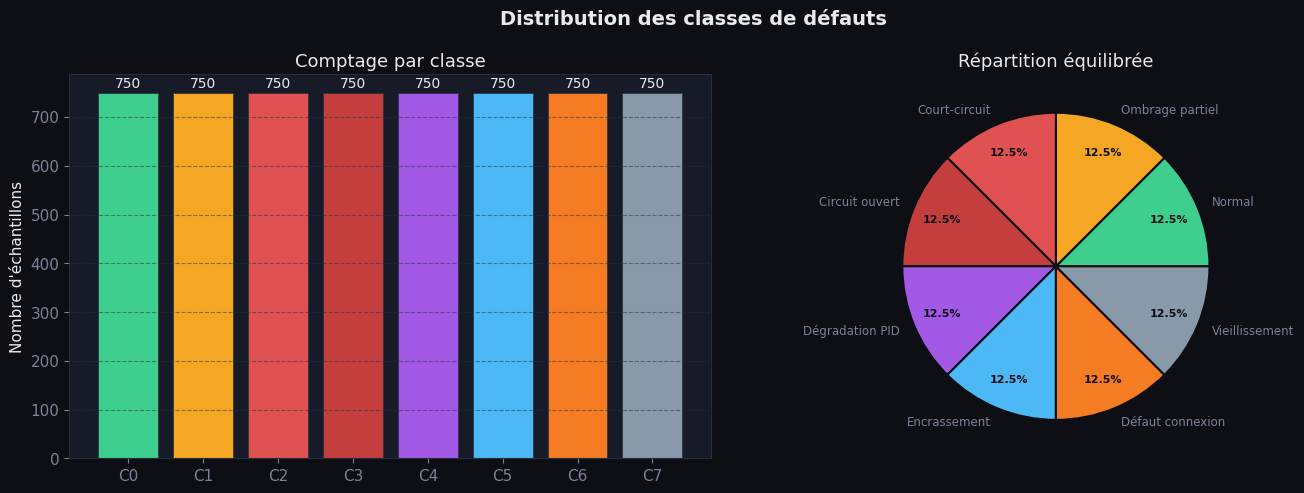

Dataset parfaitement équilibré — 750 échantillons par classe (12.5 %)


In [3]:
# ── Distribution des classes ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des classes de défauts', fontsize=14, fontweight='bold')

counts = df['classe'].value_counts().sort_index()

# Bar chart
bars = axes[0].bar(range(8), counts.values, color=COLORS, edgecolor='#252d3f', linewidth=0.5)
axes[0].set_xticks(range(8))
axes[0].set_xticklabels([f'C{i}' for i in range(8)])
axes[0].set_ylabel('Nombre d\'échantillons')
axes[0].set_title('Comptage par classe')
axes[0].grid(axis='y')
for bar, n in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(n), ha='center', va='bottom', fontsize=10, color='#e8eaf0')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=NOMS, colors=COLORS,
    autopct='%1.1f%%', pctdistance=0.8,
    wedgeprops=dict(edgecolor='#0d0f14', linewidth=1.5)
)
for t in texts:     t.set_color('#7a8299'); t.set_fontsize(8.5)
for t in autotexts: t.set_color('#0d0f14'); t.set_fontweight('bold'); t.set_fontsize(8)
axes[1].set_title('Répartition équilibrée')

plt.tight_layout()
plt.show()
print('Dataset parfaitement équilibré — 750 échantillons par classe (12.5 %)')

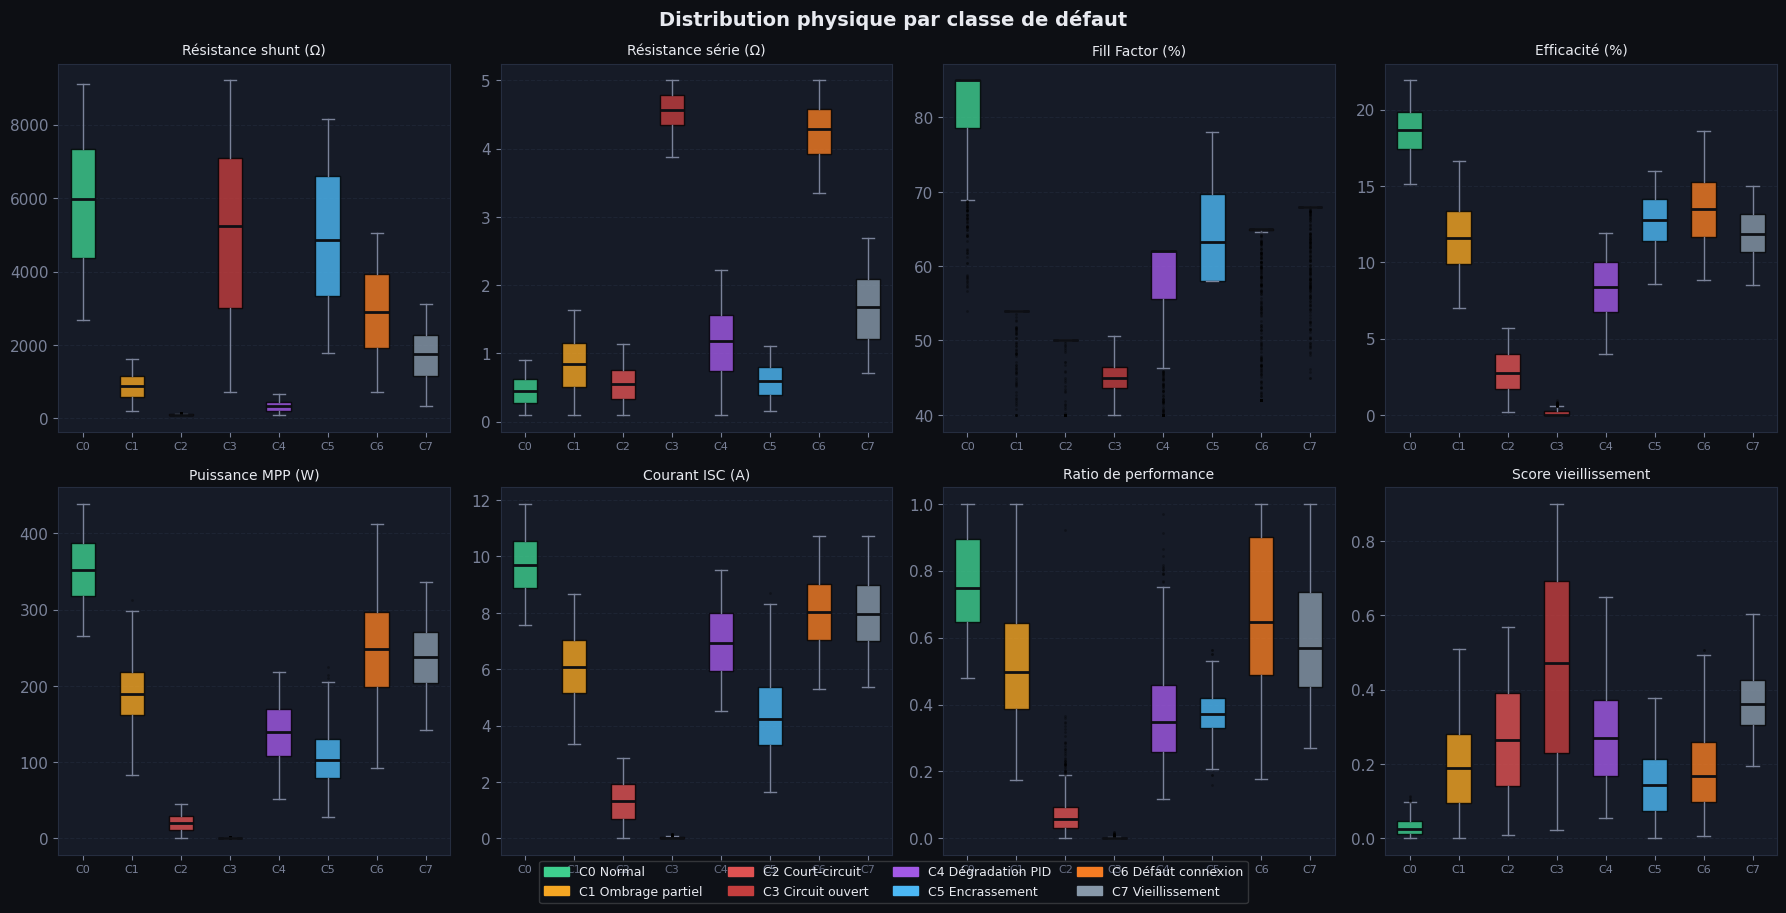

In [4]:
# ── 3. Analyse physique : boxplots des features discriminantes ────────
features_cles = [
    ('resistance_shunt',   'Résistance shunt (Ω)'),
    ('resistance_serie',   'Résistance série (Ω)'),
    ('fill_factor',        'Fill Factor (%)'),
    ('efficacite',         'Efficacité (%)'),
    ('puissance_mpp',      'Puissance MPP (W)'),
    ('courant_isc',        'Courant ISC (A)'),
    ('performance_ratio',  'Ratio de performance'),
    ('score_vieillissement','Score vieillissement'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Distribution physique par classe de défaut', fontsize=14, fontweight='bold')

for ax, (feat, label) in zip(axes.flat, features_cles):
    data_by_class = [df[df['classe'] == c][feat].values for c in range(8)]
    bp = ax.boxplot(
        data_by_class,
        patch_artist=True,
        medianprops=dict(color='#0d0f14', linewidth=2),
        whiskerprops=dict(color='#7a8299'),
        capprops=dict(color='#7a8299'),
        flierprops=dict(marker='.', markersize=2, alpha=0.3),
    )
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticklabels([f'C{i}' for i in range(8)], fontsize=8)
    ax.set_title(label, fontsize=10)
    ax.grid(axis='y')

# Légende
legend_patches = [mpatches.Patch(color=COLORS[i], label=f'C{i} {NOMS[i]}') for i in range(8)]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=9,
           framealpha=0.2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

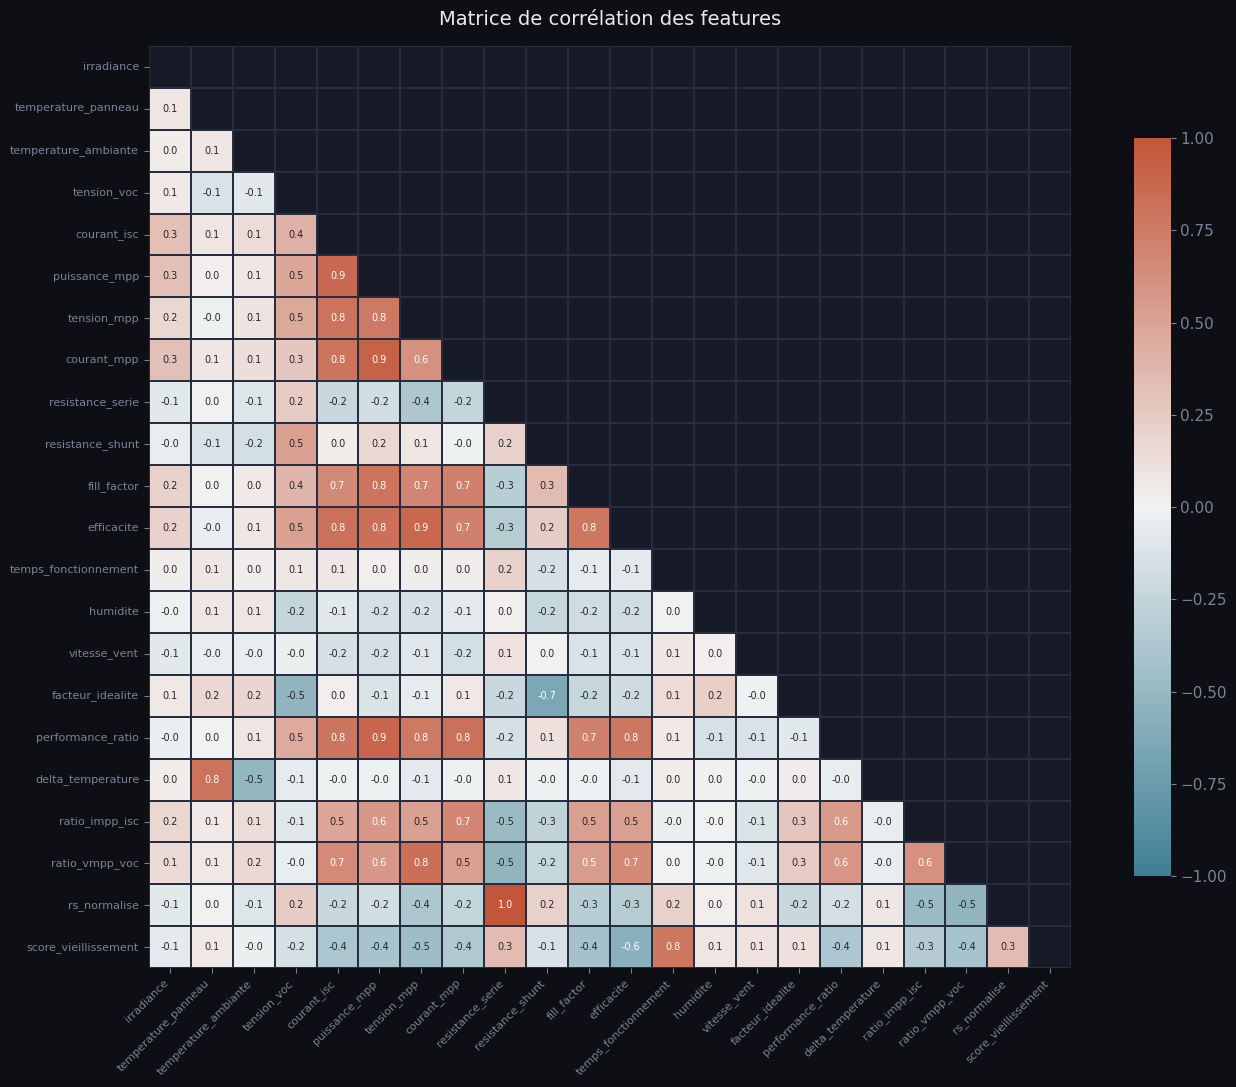

In [5]:
# ── Matrice de corrélation ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
corr = df[ALL_FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.3,
    linecolor='#252d3f', annot=True, fmt='.1f',
    annot_kws={'size': 7}, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de corrélation des features', fontsize=14, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# ── 4. Entraînement avec cross-validation ───────────────────────────
X = df[ALL_FEATURES]
y = df['classe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
clf.fit(X_train, y_train)

# Cross-validation stratifiée 5-fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print('=' * 55)
print('  MÉTRIQUES DU MODÈLE')
print('=' * 55)
print(f'  Accuracy (test)  : {clf.score(X_test, y_test)*100:.2f} %')
print(f'  CV Accuracy      : {cv_scores.mean()*100:.2f} % ± {cv_scores.std()*100:.2f} %')
print(f'  CV scores        : {[f"{s*100:.1f}%" for s in cv_scores]}')
print('=' * 55)
print()
print(classification_report(y_test, clf.predict(X_test), target_names=NOMS))

  MÉTRIQUES DU MODÈLE
  Accuracy (test)  : 99.92 %
  CV Accuracy      : 99.93 % ± 0.06 %
  CV scores        : ['100.0%', '99.9%', '99.9%', '100.0%', '99.8%']

                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00       150
 Ombrage partiel       1.00      1.00      1.00       150
   Court-circuit       1.00      1.00      1.00       150
  Circuit ouvert       1.00      1.00      1.00       150
 Dégradation PID       0.99      1.00      1.00       150
    Encrassement       1.00      1.00      1.00       150
Défaut connexion       1.00      1.00      1.00       150
  Vieillissement       1.00      0.99      1.00       150

        accuracy                           1.00      1200
       macro avg       1.00      1.00      1.00      1200
    weighted avg       1.00      1.00      1.00      1200



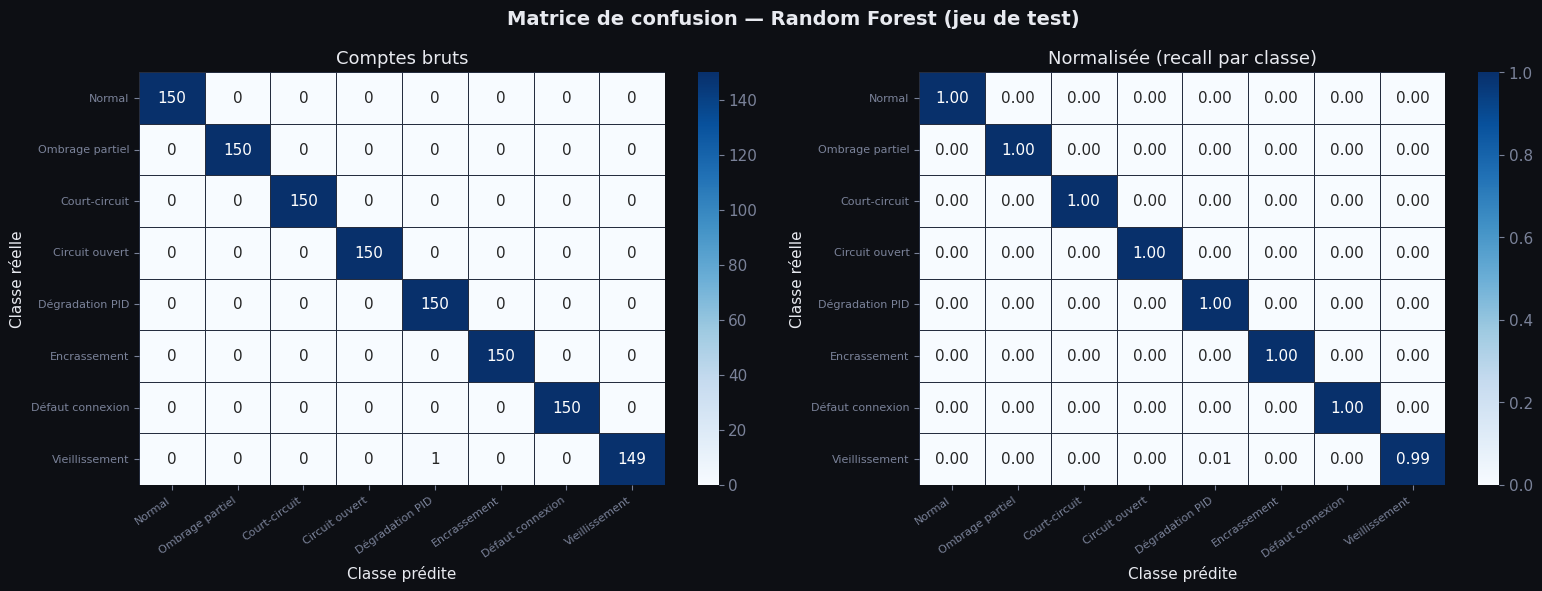

In [7]:
# ── 5. Matrice de confusion ──────────────────────────────────────────
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matrice de confusion — Random Forest (jeu de test)', fontsize=14, fontweight='bold')

# Valeurs brutes
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=NOMS, yticklabels=NOMS,
    linewidths=0.5, linecolor='#252d3f',
    ax=axes[0]
)
axes[0].set_title('Comptes bruts')
axes[0].set_xlabel('Classe prédite')
axes[0].set_ylabel('Classe réelle')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)

# Normalisée (recall par classe)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=NOMS, yticklabels=NOMS,
    vmin=0, vmax=1, linewidths=0.5, linecolor='#252d3f',
    ax=axes[1]
)
axes[1].set_title('Normalisée (recall par classe)')
axes[1].set_xlabel('Classe prédite')
axes[1].set_ylabel('Classe réelle')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha='right', fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

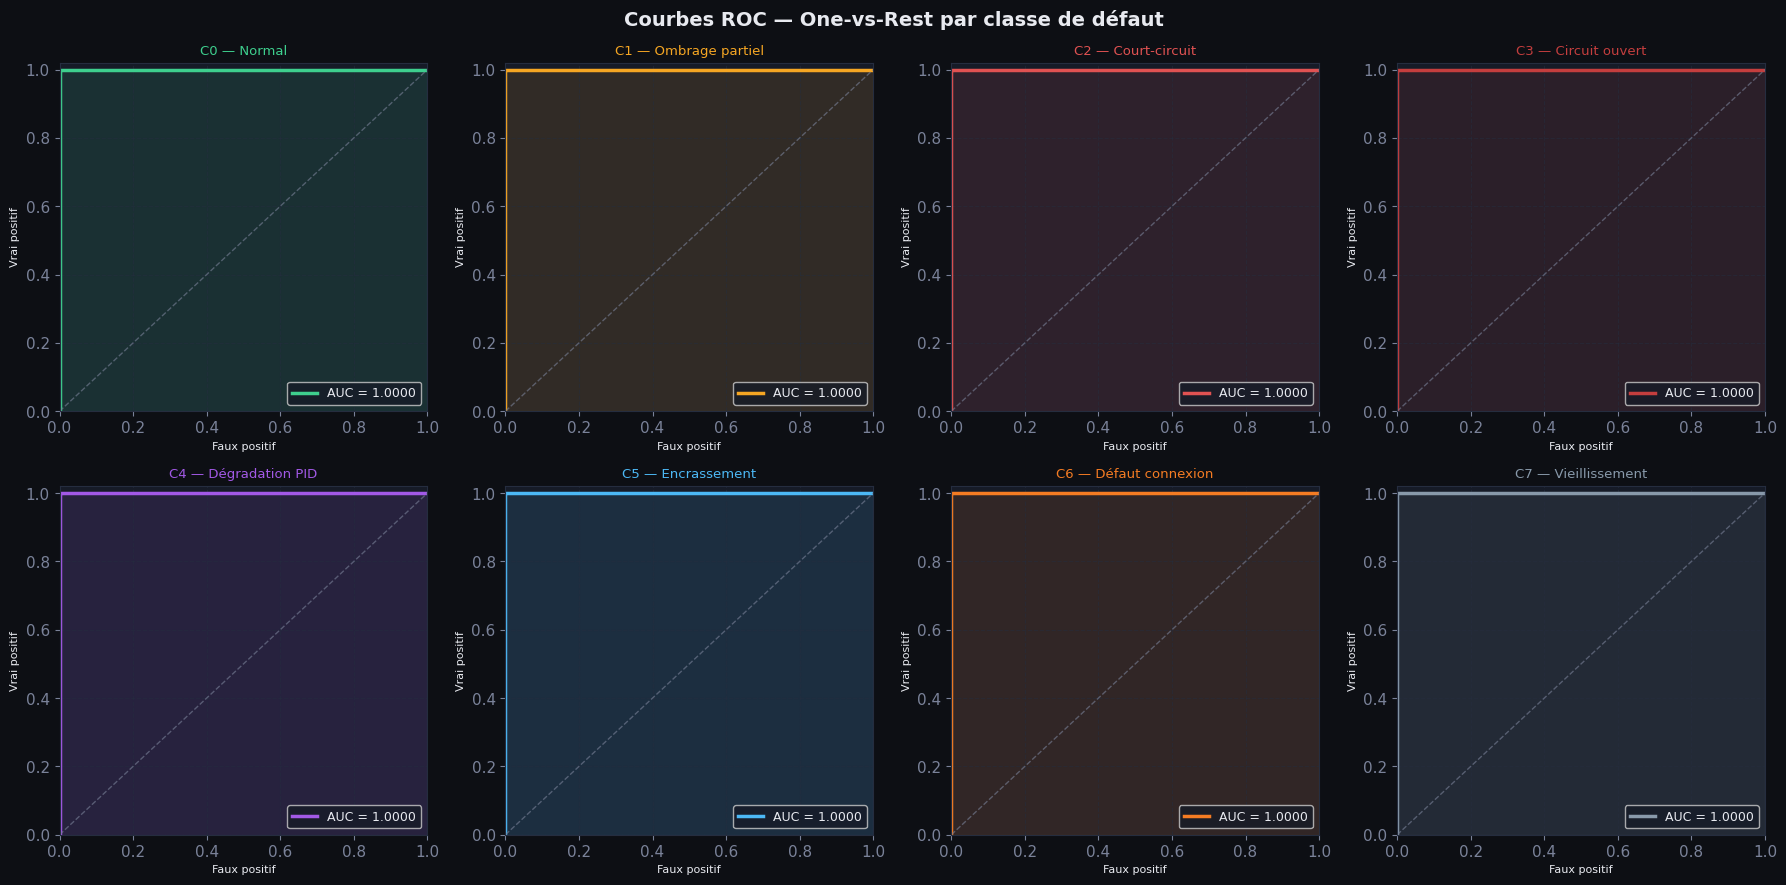

AUC moyen toutes classes : 1.000000
  C0 Normal                    AUC = 1.0000
  C1 Ombrage partiel           AUC = 1.0000
  C2 Court-circuit             AUC = 1.0000
  C3 Circuit ouvert            AUC = 1.0000
  C4 Dégradation PID           AUC = 1.0000
  C5 Encrassement              AUC = 1.0000
  C6 Défaut connexion          AUC = 1.0000
  C7 Vieillissement            AUC = 1.0000


In [8]:
# ── 6. Courbes ROC — One vs Rest ─────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=list(range(8)))
y_score    = clf.predict_proba(X_test)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Courbes ROC — One-vs-Rest par classe de défaut', fontsize=14, fontweight='bold')

aucs = []
for i, ax in enumerate(axes.flat):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    ax.plot(fpr, tpr, color=PALETTE[i], lw=2.5, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], '--', color='#7a8299', lw=1, alpha=0.6)
    ax.fill_between(fpr, tpr, alpha=0.12, color=PALETTE[i])

    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_title(f'C{i} — {NOMS[i]}', fontsize=9.5, color=PALETTE[i])
    ax.set_xlabel('Faux positif', fontsize=8)
    ax.set_ylabel('Vrai positif', fontsize=8)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True)

plt.tight_layout()
plt.show()
print(f'AUC moyen toutes classes : {np.mean(aucs):.6f}')
for i, a in enumerate(aucs):
    print(f'  C{i} {NOMS[i]:<25} AUC = {a:.4f}')

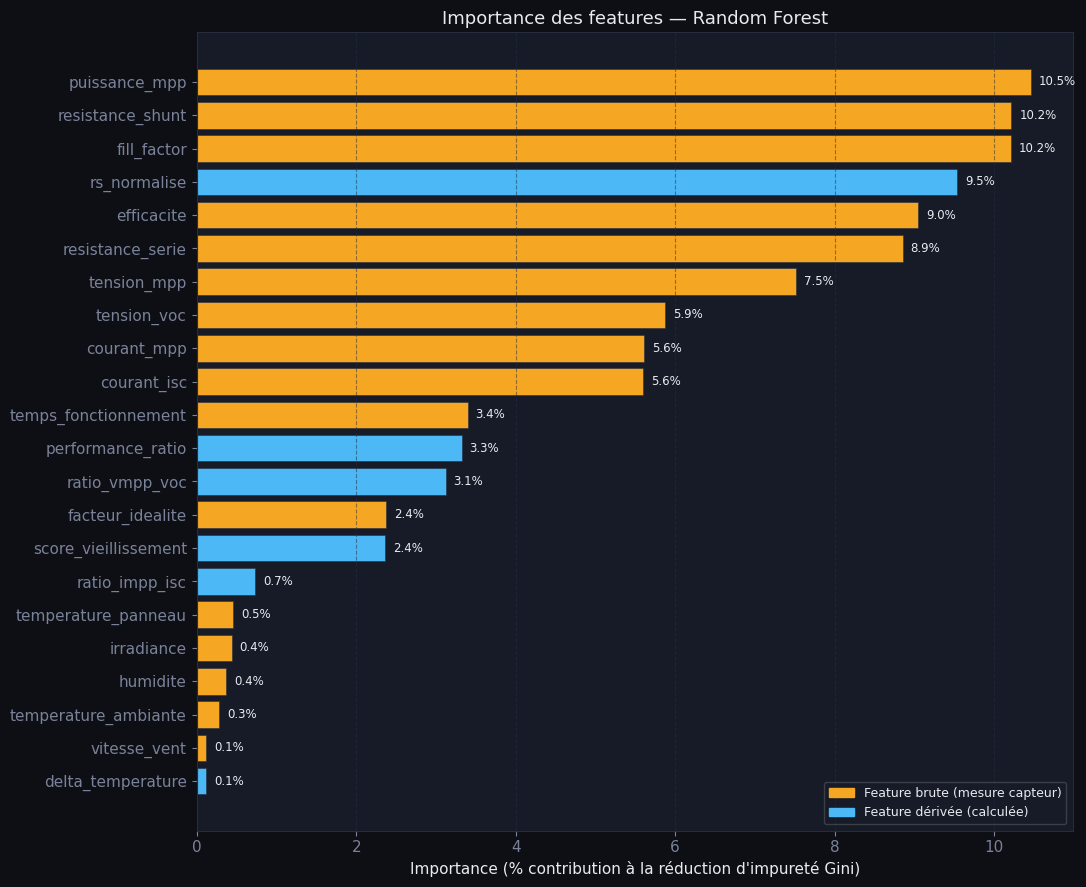


Top 5 features les plus discriminantes :
  puissance_mpp                10.46%  [brute]
  resistance_shunt             10.21%  [brute]
  fill_factor                  10.21%  [brute]
  rs_normalise                  9.54%  [dérivée]
  efficacite                    9.04%  [brute]


In [9]:
# ── 7. Importance des features ────────────────────────────────────────
importances = pd.Series(clf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))

# Colorier différemment brutes vs dérivées
colors_bar = [
    '#f5a623' if feat in FEATURES_BRUTES else '#4cb8f5'
    for feat in importances.index
]

bars = ax.barh(importances.index, importances.values * 100,
               color=colors_bar, edgecolor='#252d3f', linewidth=0.4)

# Valeurs sur les barres
for bar, val in zip(bars, importances.values * 100):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8.5, color='#e8eaf0')

ax.set_xlabel('Importance (% contribution à la réduction d\'impureté Gini)')
ax.set_title('Importance des features — Random Forest', fontsize=13)
ax.grid(axis='x')

# Légende
legend_patches = [
    mpatches.Patch(color='#f5a623', label='Feature brute (mesure capteur)'),
    mpatches.Patch(color='#4cb8f5', label='Feature dérivée (calculée)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9, framealpha=0.2)

plt.tight_layout()
plt.show()

print('\nTop 5 features les plus discriminantes :')
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    src = 'brute' if feat in FEATURES_BRUTES else 'dérivée'
    print(f'  {feat:<28} {imp*100:5.2f}%  [{src}]')

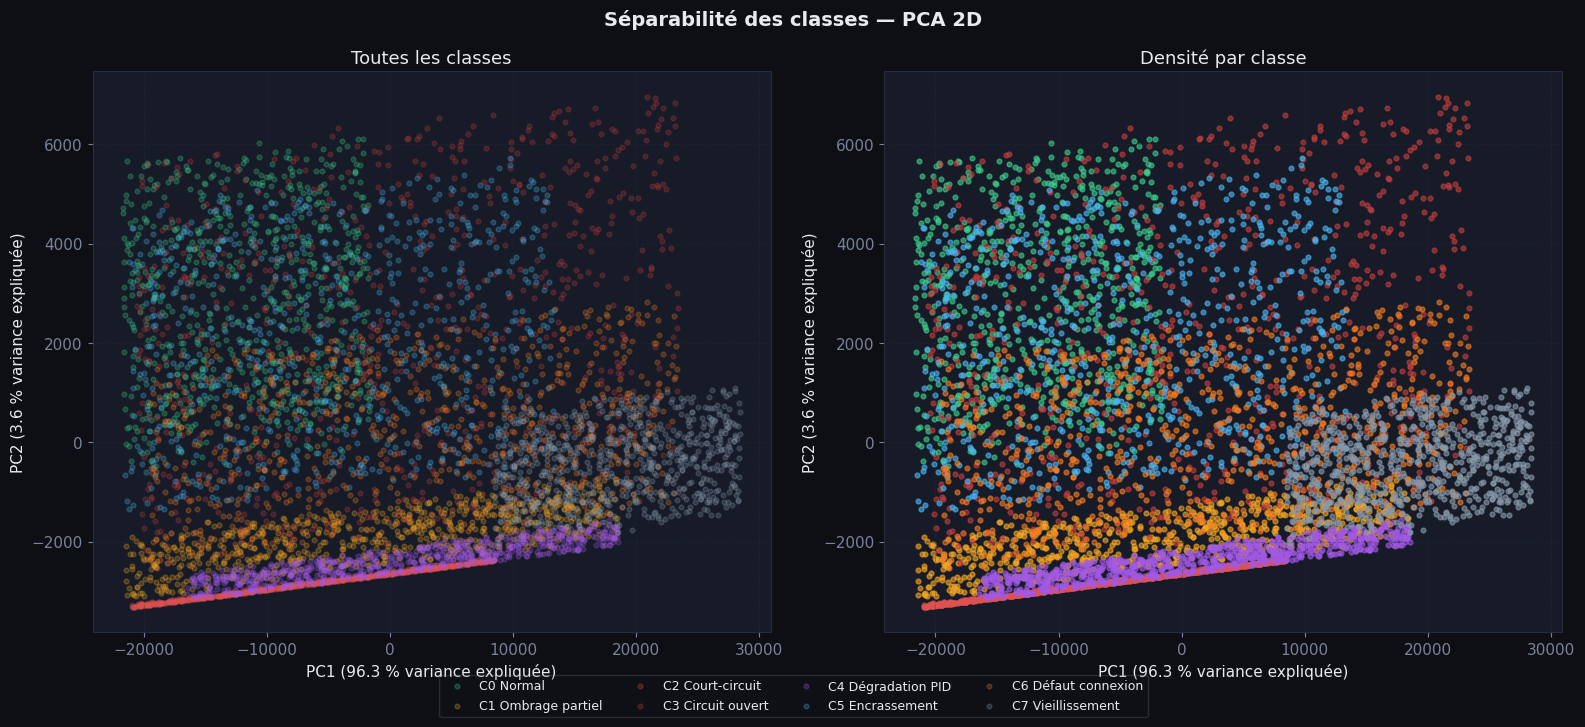

Variance expliquée : PC1=96.3% | PC2=3.6% | Total=100.0%


In [10]:
# ── 8. Séparabilité PCA 2D ────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_2d  = pca.fit_transform(X)
var   = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Séparabilité des classes — PCA 2D', fontsize=14, fontweight='bold')

for ax, alpha, title in zip(axes, [0.25, 0.6], ['Toutes les classes', 'Densité par classe']):
    for cls in range(8):
        mask = y.values == cls
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=PALETTE[cls], alpha=alpha, s=12,
            label=f'C{cls} {NOMS[cls]}'
        )
    ax.set_xlabel(f'PC1 ({var[0]:.1f} % variance expliquée)')
    ax.set_ylabel(f'PC2 ({var[1]:.1f} % variance expliquée)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

# Légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=9,
           framealpha=0.15, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()
print(f'Variance expliquée : PC1={var[0]:.1f}% | PC2={var[1]:.1f}% | Total={sum(var):.1f}%')

Nombre total d'erreurs : 1 / 1200 (0.08 %)

Confusions les plus fréquentes :
  libelle_reel  libelle_predit  count
Vieillissement Dégradation PID      1



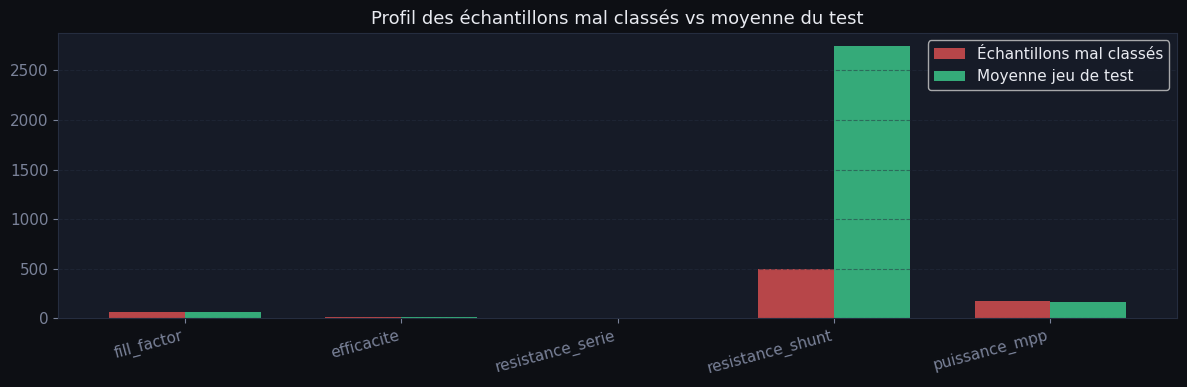

In [11]:
# ── 9. Analyse des erreurs ────────────────────────────────────────────
erreurs_idx = y_test.values != y_pred
df_erreurs  = X_test[erreurs_idx].copy()
df_erreurs['classe_reelle']  = y_test.values[erreurs_idx]
df_erreurs['classe_predite'] = y_pred[erreurs_idx]
df_erreurs['libelle_reel']   = df_erreurs['classe_reelle'].map(dict(enumerate(NOMS)))
df_erreurs['libelle_predit'] = df_erreurs['classe_predite'].map(dict(enumerate(NOMS)))

print(f'Nombre total d\'erreurs : {len(df_erreurs)} / {len(y_test)} ({len(df_erreurs)/len(y_test)*100:.2f} %)')
print()

if len(df_erreurs) > 0:
    # Couples d'erreurs les plus fréquents
    couples = df_erreurs.groupby(['libelle_reel', 'libelle_predit']).size() \
                         .reset_index(name='count') \
                         .sort_values('count', ascending=False)
    print('Confusions les plus fréquentes :')
    print(couples.to_string(index=False))
    print()

    # Visualisation des features des échantillons mal classés
    fig, ax = plt.subplots(figsize=(12, 4))
    features_viz = ['fill_factor', 'efficacite', 'resistance_serie', 'resistance_shunt', 'puissance_mpp']
    
    x_pos = np.arange(len(features_viz))
    width = 0.35
    
    mean_erreurs = df_erreurs[features_viz].mean()
    mean_total   = X_test[features_viz].mean()
    
    bars1 = ax.bar(x_pos - width/2, mean_erreurs.values, width,
                   label='Échantillons mal classés', color='#e05252', alpha=0.8)
    bars2 = ax.bar(x_pos + width/2, mean_total.values, width,
                   label='Moyenne jeu de test',       color='#3ecf8e', alpha=0.8)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(features_viz, rotation=15, ha='right')
    ax.set_title('Profil des échantillons mal classés vs moyenne du test')
    ax.legend()
    ax.grid(axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('Aucune erreur — le modèle a classé tous les échantillons correctement !')

In [12]:
# ── 10. Résumé final ─────────────────────────────────────────────────
print('=' * 60)
print('  BILAN DU MODÈLE — Solar AI Diagnostic')
print('=' * 60)
print(f'  Dataset          : {len(df):,} échantillons · {len(ALL_FEATURES)} features · 8 classes')
print(f'  Accuracy test    : {clf.score(X_test, y_test)*100:.2f} %')
print(f'  CV 5-fold        : {cv_scores.mean()*100:.2f} % ± {cv_scores.std()*100:.2f} %')
print(f'  AUC moyen ROC    : {np.mean(aucs):.6f}')
print(f'  Erreurs test     : {erreurs_idx.sum()} / {len(y_test)}')
print()
print('  Top 3 features discriminantes :')
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f'    • {feat:<28} {imp*100:.2f} %')
print()
print('  AUC par classe :')
for i, a in enumerate(aucs):
    bar = '█' * int(a * 20)
    print(f'    C{i} {NOMS[i]:<25} {bar:<20} {a:.4f}')
print('=' * 60)

  BILAN DU MODÈLE — Solar AI Diagnostic
  Dataset          : 6,000 échantillons · 22 features · 8 classes
  Accuracy test    : 99.92 %
  CV 5-fold        : 99.93 % ± 0.06 %
  AUC moyen ROC    : 1.000000
  Erreurs test     : 1 / 1200

  Top 3 features discriminantes :
    • puissance_mpp                10.46 %
    • resistance_shunt             10.21 %
    • fill_factor                  10.21 %

  AUC par classe :
    C0 Normal                    ████████████████████ 1.0000
    C1 Ombrage partiel           ████████████████████ 1.0000
    C2 Court-circuit             ████████████████████ 1.0000
    C3 Circuit ouvert            ████████████████████ 1.0000
    C4 Dégradation PID           ████████████████████ 1.0000
    C5 Encrassement              ████████████████████ 1.0000
    C6 Défaut connexion          ████████████████████ 1.0000
    C7 Vieillissement            ████████████████████ 1.0000
